# EllPHi — n-dimensional demo (n=3)

This notebook extends the quick-start example to a 3-D point cloud and demonstrates that the tangency solver, ellipse cloud builder, and pairwise distance pipeline work natively in higher dimensions.

Steps covered:
1. Build a noisy 3-D filamentary dataset.
2. Convert it into an ellipsoid cloud with local covariance estimates.
3. Visualize representative ellipsoids.
4. Solve tangency queries and assemble the condensed distance matrix.

In [1]:
import numpy
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.spatial.distance import squareform

import ellphi

In [2]:
%matplotlib inline

## Construct a synthetic 3-D filament

Points lie on a twisted filament embedded in 3-D and are perturbed by Gaussian noise.

In [3]:
rng = numpy.random.default_rng(seed=20251109)
num_points = 150
theta = numpy.linspace(0, 4 * numpy.pi, num_points)
radius = 1.0 + 0.08 * numpy.sin(3 * theta)
x = radius * numpy.cos(theta)
y = 0.6 * radius * numpy.sin(theta)
z = 0.45 * numpy.sin(2 * theta)
noise = rng.normal(scale=0.10, size=(num_points, 3))
data = numpy.column_stack((x, y, z)) + noise
data.shape

(150, 3)

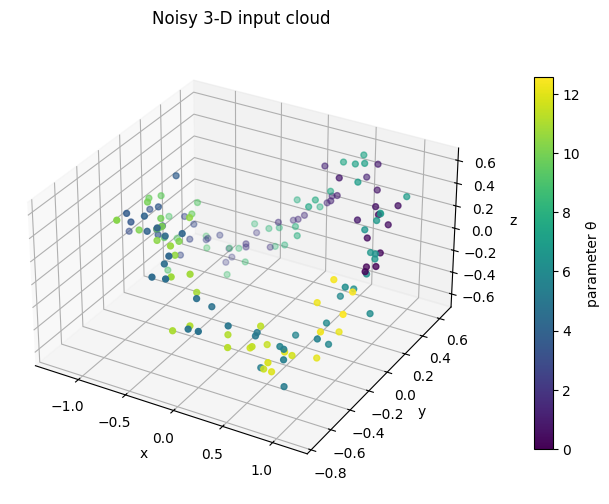

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
scatter = ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=theta, cmap="viridis", s=18)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Noisy 3-D input cloud")
ax.set_box_aspect((1, 1, 0.6))
fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.1, label="parameter θ")
plt.show()

## Build a 3-D ellipsoid cloud

`EllipseCloud.from_point_cloud` computes local covariances (k-NN neighborhoods) and stores the resulting ellipsoid coefficients.

In [5]:
ellcloud = ellphi.EllipseCloud.from_point_cloud(data, k=6)
print(ellcloud)

EllipseCloud(coef=array<(120, 10)>, mean=array<(120, 3)>, cov=array<(120, 3, 3)>, k=6, nbd=array<(120, 6)>)


## Visualize representative ellipsoids

The helper below renders an ellipsoid surface from a mean/covariance pair so we can inspect a subset in 3-D.

In [6]:
def plot_ellipsoid(
    ax, center, cov, *, color, alpha=0.3, n_meridians=40, n_parallels=20, scale=1
):
    eigvals, eigvecs = numpy.linalg.eigh(cov)
    radii = numpy.sqrt(numpy.clip(eigvals, 1e-12, None))
    u = numpy.linspace(0.0, 2 * numpy.pi, n_meridians)
    v = numpy.linspace(0.0, numpy.pi, n_parallels)
    uu, vv = numpy.meshgrid(u, v)
    sphere = numpy.stack(
        (
            numpy.cos(uu) * numpy.sin(vv),
            numpy.sin(uu) * numpy.sin(vv),
            numpy.cos(vv),
        ),
        axis=-1,
    )
    scaled = sphere * radii * scale
    rotated = scaled @ eigvecs.T
    coords = rotated + center
    ax.plot_surface(
        coords[..., 0],
        coords[..., 1],
        coords[..., 2],
        rstride=1,
        cstride=1,
        color=color,
        alpha=alpha,
        linewidth=0,
        antialiased=True,
        shade=False,
    )

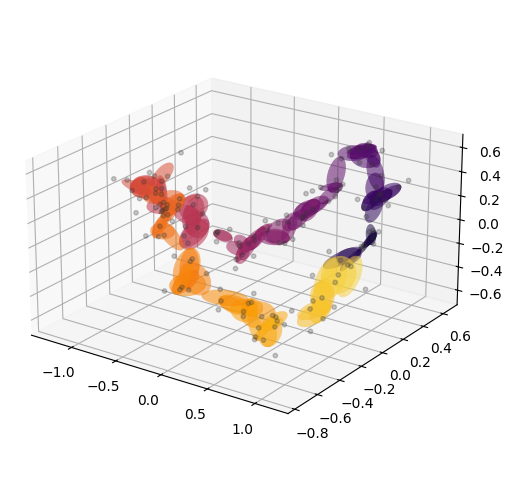

In [7]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(*data.T, s=10, alpha=0.25, color="0.2")
colors = cm.inferno(numpy.linspace(0.1, 0.9, ellcloud.n))
for idx, color in enumerate(colors):
    plot_ellipsoid(ax, ellcloud.mean[idx], ellcloud.cov[idx], color=color, alpha=0.35)
ax.set_box_aspect((1, 1, 0.6))
ax.view_init(elev=22, azim=-55)
plt.show()

## Solve a tangency query

The tangency solver now operates on 3-D ellipsoids; the returned point belongs to both quadric surfaces.

In [8]:
i, j = 4, 57
result = ellphi.tangency(ellcloud[i], ellcloud[j])
result

TangencyResult(t=15.709031584182283, point=array([ 0.28045899,  0.36269832, -0.40234144]), mu=0.5470104867093752)

In [9]:
ellphi.quad_eval(ellcloud[i], result.point), ellphi.quad_eval(ellcloud[j], result.point)

(246.77367331283676, 246.77367331283654)

## Pairwise tangency distances in 3-D

`pdist_tangency` returns the condensed distance vector (compatible with `scipy.spatial.distance.squareform`) just like in 2-D.

In [10]:
d_condensed = ellphi.pdist_tangency(ellcloud)
dist = squareform(d_condensed)
dist.shape

(120, 120)

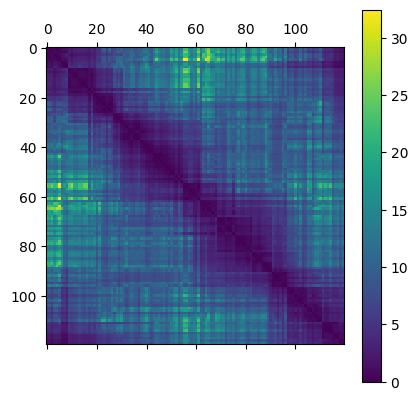

In [11]:
plt.matshow(dist)
plt.colorbar()
plt.show()

The condensed distances can now feed a persistent-homology backend (Ripser, HomCloud, etc.) without any changes to the downstream pipeline.

## Persistent homology with HomCloud

With the tangency distance matrix `dist` available, we can hand it to [HomCloud](https://homcloud.dev/) to build a Vietoris–Rips filtration and visualise the resulting persistence diagrams. This mirrors the 2-D quick-start workflow but now uses the 3-D ellipsoid cloud constructed above.

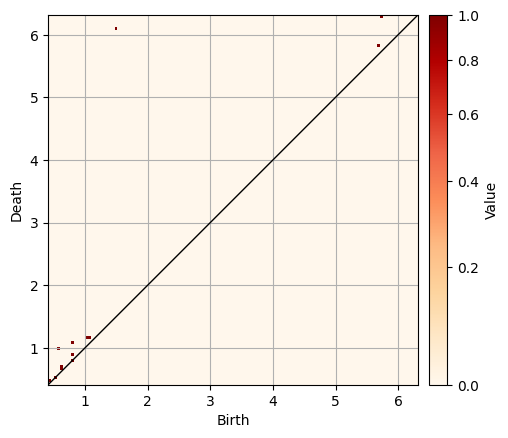

In [12]:
import homcloud.interface as hc

hc.PDList.from_rips_filtration(
    dist,
    maxdim=2,
    save_to="rips-ndim-demo.pdgm",
    save_graph=True,
)
pdlist = hc.PDList("rips-ndim-demo.pdgm")
pd1 = pdlist.dth_diagram(1)
pd1.histogram().plot(colorbar={"type": "loglog"})
plt.show()

In [13]:
bd = max(pd1.pairs(), key=lambda p: p.death_time() - p.birth_time())
optimal_1_cycle = bd.optimal_1_cycle()
bd, optimal_1_cycle.boundary_points()

(Pair(1.501007318496704, 6.097580909729004),
 [113,
  119,
  0,
  3,
  10,
  11,
  19,
  24,
  27,
  30,
  31,
  34,
  41,
  49,
  52,
  55,
  59,
  62,
  66,
  71,
  72,
  80,
  83,
  90,
  92,
  95,
  97,
  100,
  107])

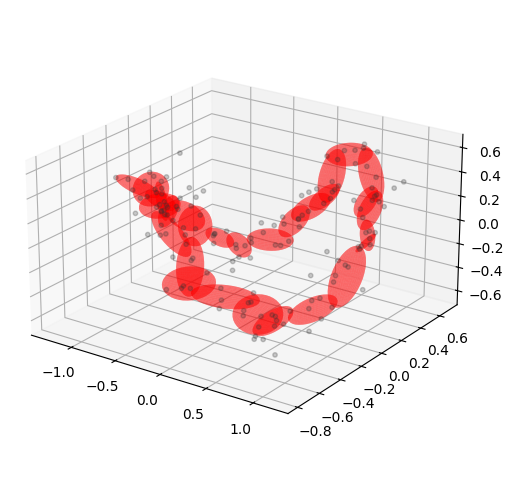

In [14]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
ax.scatter(*data.T, s=10, alpha=0.25, color="0.2")
for idx in optimal_1_cycle.boundary_points():
    plot_ellipsoid(
        ax,
        ellcloud.mean[idx],
        ellcloud.cov[idx],
        color="red",
        alpha=0.35,
        scale=bd.birth_time(),
    )
ax.set_box_aspect((1, 1, 0.6))
ax.view_init(elev=22, azim=-55)
plt.show()